In [ ]:
# The code below produces a plot of the symmetric Meixner Pollaczek Poisson flow as described in the paper:
# "Visualising the flows of orthogonal polynomial expansions of the Riemann Xi-function".
# The program reads the file with pre-computed coefficients and produces an implicit plot, 
# i.e. it visualises the flow of the real roots when r varies. 
# Version 1.1, December 19, 2025. 

In [492]:
#Meixner Pollaczek coefficients precomputation Xi(t)
DRF=RealBallField(1224)
CCF=ComplexBallField(1224)

def Phi(x):
    termexp2x=-1*DRF(pi)*DRF(2*x).exp()
    termexp5x= 6*DRF(pi)*DRF(5*x/2).exp()
    termexp9x= 4*DRF(pi)*DRF(pi)*DRF(9*x/2).exp()
    sum=(DRF(0))
    for n in range(12):
        summand =  ((n+1)^4*termexp9x-(n+1)^2*termexp5x)*((n+1)^2*termexp2x).exp()   
        sum = sum + summand
    return sum

def integrand(n,x,a):
    term1=(CCF(x/2).tanh()).pow(n) / ((x/2).cosh()).pow(2 * a)
    integr=term1*Phi(x.abs())
    return integr

def mpn(n,a,M):
    res= 2*CCF.integral(lambda y, _: integrand(n,y,a), 0, M)
    return real_part(res)

def genmpcoeffs(a,N,M):
    f = open("Meixpollcoeffa30New", "w")
    for n in range(N):
        f.write(str(mpn(2*n,a,M).mid()));f.write("\r\n")
        f.write(str("0"));f.write("\r\n")
    f.close() 
    return 0

#genmpcoeffs(lambda, nr of coefficients / 2, integral limits)
genmpcoeffs(CCF("30"),250,100)

0

Automated checks:
The sum of all the coefficients is   : 17540632346.5840377807617188 = Xi(0.5i) = 17540632346.5840377807617188 (should be equal).
d/dr z_3(0) via Newton approximation : 46.633593 versus formula: 46.609300 (should be close).
Ensure 20 digits accuracy at t = 60  : -0.00000000000000000000 (should show 20 zeros).


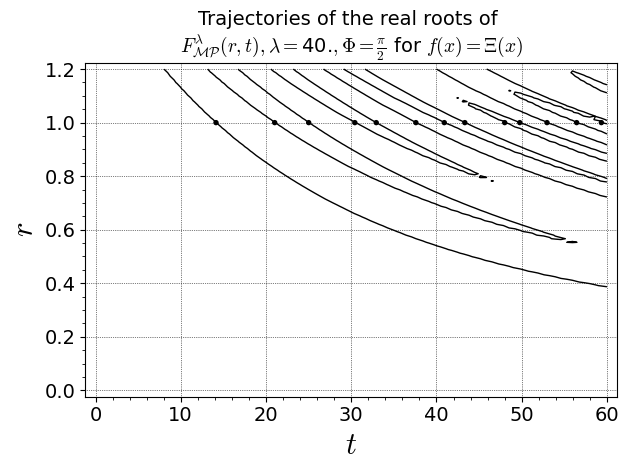

In [510]:
#Meixner Pollaczek flow of Xi using pre-computed coefficients.
var("r","t");

#Generate a plot of all ordinates of the non-trivial zeros < 60 to overlay the flow graphs
var('y')
global ord, ordrho; ord = []; ordrho = []
with open("ordinateszetazeros.txt", "r") as f: #file is stored on GitHub
    for row in f:
        y=float(row)
        if y < 60:
            ord.append([y,1])
        ordrho.append(y)
z=list_plot(ord, size=15, marker="o", color = "black")

CCF=ComplexBallField(1024)
RDF=RealBallField(1024)

#set alpha once here (and make sure the coefficient file for this specific alpha is loaded)
global lambd
lambd = CCF("40")

lst = str(lambd.mid()); lstr = lst.rstrip('0')

global m1; m1 = []; CoeffSum = RDF(0)
k = 0
with open("MeixPollCoeffa40New", "r") as f:
    for row in f:
        CoeffSum = CoeffSum + CCF(2*lambd+k).gamma()/(CCF(2*lambd).gamma() * RDF(k+1).gamma())*RDF(row)
        m1.append([RDF(row)])
        k = k + 1

def Xi(t):
    f=CCF("0.5",0)+I*CCF(t)
    xi=f/2*(f-1)*CCF(pi).pow(-f/2)*(f/2).gamma()*f.zeta()
    return xi

def MeixPollPoly(t,n):
    f1=CCF(lambd,0)+I*CCF(t)
    hyp=CCF(2).hypergeometric([-n,f1],[2*lambd])
    return CCF(0,1).pow(CCF(n))*CCF(2*lambd+n).gamma() / (CCF(2*lambd).gamma() * CCF(n+1).gamma()) * hyp

def MeixPollFlow(t,r):
    sum=CCF(0)
    for n in range(250):
        #g=CCF(-r,0).exp()
        g = CCF(r)
        sum=sum+g.pow(2*n)*CCF(str(m1[2*n]))*MeixPollPoly(t,2*n)*CCF(-1).pow(n)
    return real_part(sum.mid())

#compute d/dr zk Newton approximation
def dzdrzk(k):
    tr = RDF("0.0000000001");x0 = RDF(ordrho[k-1]);
    while(y):
        hd = RDF(MeixPollFlow(x0 + tr*100,1+tr) - MeixPollFlow(x0,1+tr)) / (tr*100)
        h = RDF(MeixPollFlow(x0,1+tr))/hd ;x1 = x0 - h;ab = h.abs();x0 = x1
        if ab < tr:
            break
    dzdr = -1*(x1 - RDF(ordrho[k-1])) / (tr) 
    return dzdr

#sum zeros around k-th zero
def prodzeros(k,c):
    zk =ordrho[k-1]
    prod0 = 1
    for j in range(k-1):
        prod0 = prod0 * (1 + c/(zk-ordrho[j]))*(1 + c/(zk+ordrho[j]))
    prod1 = 1
    for j in range(k+1,100001):
        prod1 = prod1 * (1 + c/(zk-ordrho[j-1]))*(1 + c/(zk+ordrho[j-1]))
    prod2 = (1 + c/(zk + zk))
    return c * prod0 * prod1 * prod2       

#compute d/dr zk via formula
def verifyDDE(k):
    return ((CCF(lambd).mid()-I*ordrho[k-1])/2)*prodzeros(k,I) +((CCF(lambd).mid()+I*ordrho[k-1])/2)*prodzeros(k,-I)

print("Automated checks:")
print("The sum of all the coefficients is   : %3.16f = Xi(0.5i) = %3.16f (should be equal)." % (CoeffSum, MeixPollFlow(CCF(lambd).mid()*I,1)))
print("d/dr z_3(0) via Newton approximation : %3.6f versus formula: %3.6f (should be close)." % (dzdrzk(3),real_part(verifyDDE(3))))
tmp = MeixPollFlow(60,1)-real_part(Xi(60).mid())
print("Ensure 20 digits accuracy at t = 60  : %3.20f (should show 20 zeros)." % tmp)

a1=implicit_plot(lambda t,r:((RDF(MeixPollFlow(t,r)))),(t,0,60),(r,0,1.2),color='black',fontsize=14,linestyle ="-",linewidth=1,axes_labels=['$t$',r'$r$'],title='Trajectories of the real roots of \n' +r'$F^\lambda_{\mathcal{MP}}(r,t), \lambda =$' + lstr + r'$, \Phi = \frac{\pi}{2}$ for $f(x)=\Xi(x)$',gridlines=True,plot_points=90)
#a1=implicit_plot(lambda t,r:((RDF(MeixPollFlow(t,r)))),(t,0,60),(r,0.4,1.1),color='black',fontsize=14,linestyle ="-",linewidth=1,axes_labels=['$t$',r'$r$'],title='Trajectories of the real roots of \n' +r'$F_{\mathcal{MP}}(r,t), \Phi = \frac{\pi}{2}$ for $f(x)=\Xi(x)$',gridlines=True,plot_points=210)
show(a1 + z,aspect_ratio='automatic')

Automated checks:
The sum of all the coefficients is   : 841789109923621156883289143960695992221696.0000000000000000 = Xi(0.5i) = 841789109923621156883289143960695992221696.0000000000000000 (should be equal).
d/dr z_3(0) via Newton approximation : 82.730149 versus formula: 82.645284 (should be close).
Ensure 20 digits accuracy at t = 60  : -0.00000000000000000000 (should show 20 zeros).


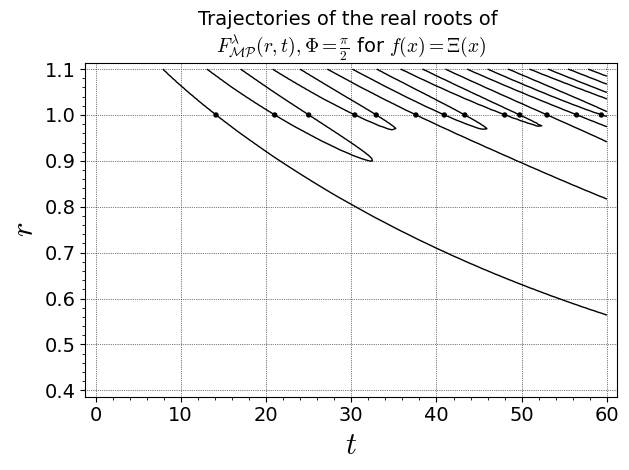

In [496]:
#Meixner Pollaczek flow of Xi using pre-computed coefficients.
var("r","t");

#Generate a plot of all ordinates of the non-trivial zeros < 60 to overlay the flow graphs
var('y')
global ord, ordrho; ord = []; ordrho = []
with open("ordinateszetazeros.txt", "r") as f: #file is stored on GitHub
    for row in f:
        y=float(row)
        if y < 60:
            ord.append([y,1])
        ordrho.append(y)
z=list_plot(ord, size=15, marker="o", color = "black")

CCF=ComplexBallField(1024)
RDF=RealBallField(1024)

#set alpha once here (and make sure the coefficient file for this specific alpha is loaded)
global lambd
lambd = CCF("100")

lst = str(lambd.mid()); lstr = lst.rstrip('0')

global m1; m1 = []; CoeffSum = RDF(0)
k = 0
with open("MeixPollCoeffa100New", "r") as f:
    for row in f:
        CoeffSum = CoeffSum + CCF(2*lambd+k).gamma()/(CCF(2*lambd).gamma() * RDF(k+1).gamma())*RDF(row)
        m1.append([RDF(row)])
        k = k + 1

def Xi(t):
    f=CCF("0.5",0)+I*CCF(t)
    xi=f/2*(f-1)*CCF(pi).pow(-f/2)*(f/2).gamma()*f.zeta()
    return xi

def MeixPollPoly(t,n):
    f1=CCF(lambd,0)+I*CCF(t)
    hyp=CCF(2).hypergeometric([-n,f1],[2*lambd])
    return CCF(0,1).pow(CCF(n))*CCF(2*lambd+n).gamma() / (CCF(2*lambd).gamma() * CCF(n+1).gamma()) * hyp

def MeixPollFlow(t,r):
    sum=CCF(0)
    for n in range(250):
        #g=CCF(-r,0).exp()
        g = CCF(r)
        sum=sum+g.pow(2*n)*CCF(str(m1[2*n]))*MeixPollPoly(t,2*n)*CCF(-1).pow(n)
    return real_part(sum.mid())

#compute d/dr zk Newton approximation
def dzdrzk(k):
    tr = RDF("0.0000000001");x0 = RDF(ordrho[k-1]);
    while(y):
        hd = RDF(MeixPollFlow(x0 + tr*100,1+tr) - MeixPollFlow(x0,1+tr)) / (tr*100)
        h = RDF(MeixPollFlow(x0,1+tr))/hd ;x1 = x0 - h;ab = h.abs();x0 = x1
        if ab < tr:
            break
    dzdr = -1*(x1 - RDF(ordrho[k-1])) / (tr) 
    return dzdr

#sum zeros around k-th zero
def prodzeros(k,c):
    zk =ordrho[k-1]
    prod0 = 1
    for j in range(k-1):
        prod0 = prod0 * (1 + c/(zk-ordrho[j]))*(1 + c/(zk+ordrho[j]))
    prod1 = 1
    for j in range(k+1,100001):
        prod1 = prod1 * (1 + c/(zk-ordrho[j-1]))*(1 + c/(zk+ordrho[j-1]))
    prod2 = (1 + c/(zk + zk))
    return c * prod0 * prod1 * prod2       

#compute d/dr zk via formula
def verifyDDE(k):
    return ((CCF(lambd).mid()-I*ordrho[k-1])/2)*prodzeros(k,I) +((CCF(lambd).mid()+I*ordrho[k-1])/2)*prodzeros(k,-I)

print("Automated checks:")
print("The sum of all the coefficients is   : %3.16f = Xi(0.5i) = %3.16f (should be equal)." % (CoeffSum, MeixPollFlow(CCF(lambd).mid()*I,1)))
print("d/dr z_3(0) via Newton approximation : %3.6f versus formula: %3.6f (should be close)." % (dzdrzk(3),real_part(verifyDDE(3))))
tmp = MeixPollFlow(60,1)-real_part(Xi(60).mid())
print("Ensure 20 digits accuracy at t = 60  : %3.20f (should show 20 zeros)." % tmp)

#a100=implicit_plot(lambda t,r:((RDF(MeixPollFlow(t,r)))),(t,0,60),(r,0,1.1),color='black',fontsize=14,linestyle ="-",linewidth=1,axes_labels=['$t$',r'$r$'],title='Trajectories of the real roots of \n' +r'$F^{\lambda}_{\mathcal{MP}}(r,t), \lambda =$' + lstr + r'$, \Phi = \frac{\pi}{2}$ for $f(x)=\Xi(x)$',gridlines=True,plot_points=90)
a100=implicit_plot(lambda t,r:((RDF(MeixPollFlow(t,r)))),(t,0,60),(r,0.4,1.1),color='black',fontsize=14,linestyle ="-",linewidth=1,axes_labels=['$t$',r'$r$'],title='Trajectories of the real roots of \n' +r'$F^{\lambda}_{\mathcal{MP}}(r,t), \Phi = \frac{\pi}{2}$ for $f(x)=\Xi(x)$',gridlines=True,plot_points=120)
show(a100 + z,aspect_ratio='automatic')

Automated checks:
The sum of all the coefficients is   : 22169687422992708560558427319511244946470241128014478232716298039414751232.0000000000000000 = Xi(0.5i) = 22169687422992708560558427319511244946470241128014478232716298039414751232.0000000000000000 (should be equal).
d/dr z_3(0) via Newton approximation : 112.810612 versus formula: 112.675270 (should be close).
Ensure 20 digits accuracy at t = 60  : 0.00000000000000000000 (should show 20 zeros).


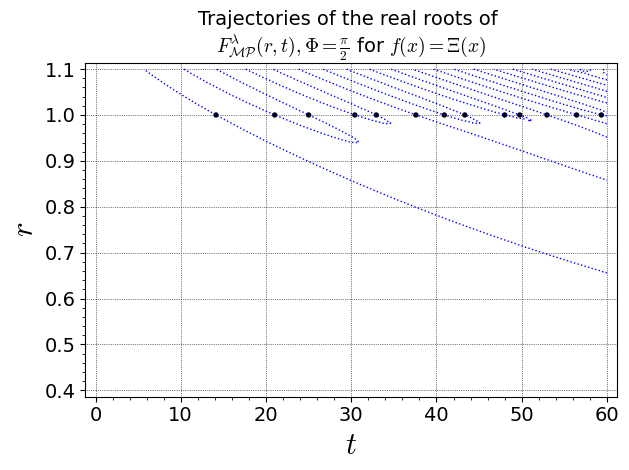

In [497]:
#Meixner Pollaczek flow of Xi using pre-computed coefficients.
var("r","t");

#Generate a plot of all ordinates of the non-trivial zeros < 60 to overlay the flow graphs
var('y')
global ord, ordrho; ord = []; ordrho = []
with open("ordinateszetazeros.txt", "r") as f: #file is stored on GitHub
    for row in f:
        y=float(row)
        if y < 60:
            ord.append([y,1])
        ordrho.append(y)
z=list_plot(ord, size=15, marker="o", color = "black")

CCF=ComplexBallField(1024)
RDF=RealBallField(1024)

#set alpha once here (and make sure the coefficient file for this specific alpha is loaded)
global lambd
lambd = CCF("150")

lst = str(lambd.mid()); lstr = lst.rstrip('0')

global m1; m1 = []; CoeffSum = RDF(0)
k = 0
with open("MeixPollCoeffa150New", "r") as f:
    for row in f:
        CoeffSum = CoeffSum + CCF(2*lambd+k).gamma()/(CCF(2*lambd).gamma() * RDF(k+1).gamma())*RDF(row)
        m1.append([RDF(row)])
        k = k + 1

def Xi(t):
    f=CCF("0.5",0)+I*CCF(t)
    xi=f/2*(f-1)*CCF(pi).pow(-f/2)*(f/2).gamma()*f.zeta()
    return xi

def MeixPollPoly(t,n):
    f1=CCF(lambd,0)+I*CCF(t)
    hyp=CCF(2).hypergeometric([-n,f1],[2*lambd])
    return CCF(0,1).pow(CCF(n))*CCF(2*lambd+n).gamma() / (CCF(2*lambd).gamma() * CCF(n+1).gamma()) * hyp

def MeixPollFlow(t,r):
    sum=CCF(0)
    for n in range(250):
        #g=CCF(-r,0).exp()
        g = CCF(r)
        sum=sum+g.pow(2*n)*CCF(str(m1[2*n]))*MeixPollPoly(t,2*n)*CCF(-1).pow(n)
    return real_part(sum.mid())

#compute d/dr zk Newton approximation
def dzdrzk(k):
    tr = RDF("0.0000000001");x0 = RDF(ordrho[k-1]);
    while(y):
        hd = RDF(MeixPollFlow(x0 + tr*100,1+tr) - MeixPollFlow(x0,1+tr)) / (tr*100)
        h = RDF(MeixPollFlow(x0,1+tr))/hd ;x1 = x0 - h;ab = h.abs();x0 = x1
        if ab < tr:
            break
    dzdr = -1*(x1 - RDF(ordrho[k-1])) / (tr) 
    return dzdr

#sum zeros around k-th zero
def prodzeros(k,c):
    zk =ordrho[k-1]
    prod0 = 1
    for j in range(k-1):
        prod0 = prod0 * (1 + c/(zk-ordrho[j]))*(1 + c/(zk+ordrho[j]))
    prod1 = 1
    for j in range(k+1,100001):
        prod1 = prod1 * (1 + c/(zk-ordrho[j-1]))*(1 + c/(zk+ordrho[j-1]))
    prod2 = (1 + c/(zk + zk))
    return c * prod0 * prod1 * prod2       

#compute d/dr zk via formula
def verifyDDE(k):
    return ((CCF(lambd).mid()-I*ordrho[k-1])/2)*prodzeros(k,I) +((CCF(lambd).mid()+I*ordrho[k-1])/2)*prodzeros(k,-I)

print("Automated checks:")
print("The sum of all the coefficients is   : %3.16f = Xi(0.5i) = %3.16f (should be equal)." % (CoeffSum, MeixPollFlow(CCF(lambd).mid()*I,1)))
print("d/dr z_3(0) via Newton approximation : %3.6f versus formula: %3.6f (should be close)." % (dzdrzk(3),real_part(verifyDDE(3))))
tmp = MeixPollFlow(60,1)-real_part(Xi(60).mid())
print("Ensure 20 digits accuracy at t = 60  : %3.20f (should show 20 zeros)." % tmp)

#a150=implicit_plot(lambda t,r:((RDF(MeixPollFlow(t,r)))),(t,0,60),(r,0,1.1),color='blue',fontsize=14,linestyle =":",linewidth=1,axes_labels=['$t$',r'$r$'],title='Trajectories of the real roots of \n' +r'$F_{\mathcal{MP}}(r,t), \lambda =$' + lstr + r'$, \Phi = \frac{\pi}{2}$ for $f(x)=\Xi(x)$',gridlines=True,plot_points=90)
a150=implicit_plot(lambda t,r:((RDF(MeixPollFlow(t,r)))),(t,0,60),(r,0.4,1.1),color='blue',fontsize=14,linestyle =":",linewidth=1,axes_labels=['$t$',r'$r$'],title='Trajectories of the real roots of \n' +r'$F^{\lambda}_{\mathcal{MP}}(r,t), \Phi = \frac{\pi}{2}$ for $f(x)=\Xi(x)$',gridlines=True,plot_points=120)
show(a150 + z,aspect_ratio='automatic')

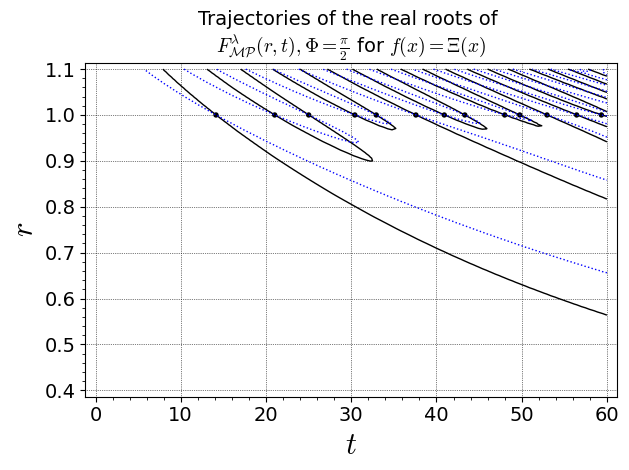

In [498]:
show(a100 + a150 + z,aspect_ratio='automatic')

In [23]:
#Meixner Pollaczek flow using a single integral for Xi (no pre-computed coefficients).

var("r","t");

#Generate a plot of all ordinates of the non-trivial zeros < 60 to overlay the flow graphs
var('y')
global ord, ordrho; ord = []; ordrho = []
with open("ordinateszetazeros.txt", "r") as f: #file is stored on GitHub
    for row in f:
        y=float(row)
        if y < 60:
            ord.append([y,1])
        ordrho.append(y)
z=list_plot(ord, size=15, marker="o", color = "black")

CCF=ComplexBallField(1024)
DRF=RealBallField(1024)

#set lambda once here
global lambd
lambd = CCF("1")

lst = str(lambd.mid()); lstr = lst.rstrip('0')

def Xi(t):
    f=CCF("0.5",0)+I*CCF(t)
    xi=f/2*(f-1)*CCF(pi).pow(-f/2)*(f/2).gamma()*f.zeta()
    return xi

def Phi(x):
    termexp2x=-1*DRF(pi)*DRF(2*x).exp()
    termexp5x= 6*DRF(pi)*DRF(5*x/2).exp()
    termexp9x= 4*DRF(pi)*DRF(pi)*DRF(9*x/2).exp()
    sum=(DRF(0))
    for n in range(12):
        summand =  ((n+1)^4*termexp9x-(n+1)^2*termexp5x)*((n+1)^2*termexp2x).exp()   
        sum = sum + summand
    return sum

def prefact(x,rho):
    term1 = Phi(2 * (x.abs()).arctanh()) * (1-x.pow(2)).pow(lambd-1) / ((1-x.pow(2) * rho.pow(2)).pow(lambd))
    return term1 

def integrand(t, x, rho):
    return prefact(x,rho)*(2*t*(x*rho).arctanh()).cos()

def MeixPollFlow(t, rho):
    res= 4*CCF.integral(lambda y, _: integrand(CCF(t), CCF(y), CCF(rho)), CCF("0"), CCF("0.999999"))
    return real_part(res.mid())

#compute d/dr zk Newton approximation
def dzdrzk(k):
    tr = RDF("0.0000000001");x0 = RDF(ordrho[k-1]);
    while(y):
        hd = RDF(MeixPollFlow(x0 + tr*100,1+tr) - MeixPollFlow(x0,1+tr)) / (tr*100)
        h = RDF(MeixPollFlow(x0,1+tr))/hd ;x1 = x0 - h;ab = h.abs();x0 = x1
        if ab < tr:
            break
    dzdr = -1*(x1 - RDF(ordrho[k-1])) / (tr) 
    return dzdr

#sum zeros around k-th zero
def prodzeros(k,c):
    zk =ordrho[k-1]
    prod0 = 1
    for j in range(k-1):
        prod0 = prod0 * (1 + c/(zk-ordrho[j]))*(1 + c/(zk+ordrho[j]))
    prod1 = 1
    for j in range(k+1,100001):
        prod1 = prod1 * (1 + c/(zk-ordrho[j-1]))*(1 + c/(zk+ordrho[j-1]))
    prod2 = (1 + c/(zk + zk))
    return c * prod0 * prod1 * prod2       

#compute d/dr zk via formula
def verifyDDE(k):
    return ((CCF(lambd).mid()-I*ordrho[k-1])/2)*prodzeros(k,I) +((CCF(lambd).mid()+I*ordrho[k-1])/2)*prodzeros(k,-I)

print("Automated checks:")
print("d/dr z_3(0) via Newton approximation : %3.6f versus formula: %3.6f (should be equal)." % ((dzdrzk(3),verifyDDE(3))))
tmp = MeixPollFlow(60,1)-real_part(Xi(60).mid())
print("Ensure 20 digits accuracy at t = 60  : %3.20f (should show 20 zeros)." % tmp)

#a100i=implicit_plot(lambda t,r:MeixPollFlow(t,r),(t,0,100),(r,0,2),color='black',fontsize=14,linestyle ="-",linewidth=1,axes_labels=['$t$',r'$r$'],title='Trajectories of the real roots of \n' + r'$F^{\lambda}_{\mathcal{MP}}(r,t), \lambda =$' + lstr + r'$, \Phi = \frac{\pi}{2}$ for $f(x)=\Xi_i(x)$',gridlines=True,plot_points=90)
a100i=implicit_plot(lambda t,r:MeixPollFlow(t,r),(t,0,100),(r,0,2),color='black',fontsize=14,linestyle ="-",linewidth=1,axes_labels=['$t$',r'$r$'],title='Trajectories of the real roots of \n' + r'$F^{\lambda}_{\mathcal{MP}}(r,t), \Phi = \frac{\pi}{2}$ for $f(x)=\Xi_i(x)$',gridlines=True,plot_points=90)
show(a100i + z1,aspect_ratio='automatic')

Automated checks:
d/dr z_3(0) via Newton approximation : 23.170832 versus formula: 23.185911 (should be equal).
Ensure 20 digits accuracy at t = 60  : -0.00000000000000000000 (should show 20 zeros).


KeyboardInterrupt: 

Automated checks:
d/dr z_3(0) via Newton approximation : 25.103171 versus formula: 25.103171 (should be equal).
Ensure 20 digits accuracy at t = 60  : 0.00000000000000000000 (should show 20 zeros).


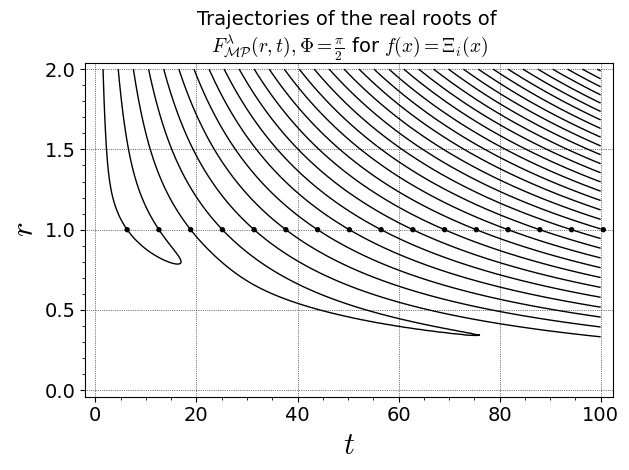

In [471]:
#Meixner Pollaczek flow using a single integral for Xi_i (no pre-computed coefficients).

var("r","t");

#Generate a plot of all ordinates of the zeros < 60 to overlay the flow graphs
var('y')
ord = []
for y in range(16):
    ord.append([2*pi()*(y+1),1])
z1=list_plot(ord, size=15, marker="o", color = "black")

CCF=ComplexBallField(1024)
RDF=RealBallField(1024)

#set lambda once here
global lambd
lambd = CCF("100")

lst = str(lambd.mid()); lstr = lst.rstrip('0')

def Xin(t):
    Xin=2*CCF(t/2).sin()/CCF(t)
    return Xin

def prefact(x,rho):
    term1 = (1-x.pow(2)).pow(lambd-1) / ((1-x.pow(2) * rho.pow(2)).pow(lambd))
    return term1 

def integrand(t, x, rho):
    return prefact(x,rho)*(2*t*(x*rho).arctanh()).cos()

def MeixPollFlow(t, rho):
    res= 4*CCF.integral(lambda y, _: integrand(CCF(t), CCF(y), CCF(rho)), CCF("0"), CCF("0.25").tanh())
    return real_part(res.mid())

#compute d/dr zk Newton approximation
def dzdrzk(k):
    tr = RDF("0.0000000001");x0 = 2*k*RDF.pi();
    while(y):
        hd = RDF(MeixPollFlow(x0 + tr*100,1+tr) - MeixPollFlow(x0,1+tr)) / (tr*100)
        h = RDF(MeixPollFlow(x0,1+tr))/hd ;x1 = x0 - h;ab = h.abs();x0 = x1
        if ab < tr:
            break
    dzdr = -1*(x1 - 2*k*RDF.pi())/(tr) 
    return dzdr

#closed form for sum of zeros around k-th zero
def ZS(k,c):
    zk =CCF(2*pi()*k)
    return 2*zk*CCF(c/2).sin()/(zk +c)    

#compute d/dr zk via formula
def verifyDDE(k):
    return real_part((lambd / CCF("2") - CCF(0,pi()*k))*ZS(k,CCF(0,1)) + (lambd / CCF("2") + CCF(0,pi()*k))*ZS(k,CCF(0,-1))).mid()

print("Automated checks:")
print("d/dr z_3(0) via Newton approximation : %3.6f versus formula: %3.6f (should be equal)." % ((dzdrzk(3),verifyDDE(3))))
tmp = MeixPollFlow(60,1)-Xin(60).mid()
print("Ensure 20 digits accuracy at t = 60  : %3.20f (should show 20 zeros)." % tmp)

#a100i=implicit_plot(lambda t,r:MeixPollFlow(t,r),(t,0,100),(r,0,2),color='black',fontsize=14,linestyle ="-",linewidth=1,axes_labels=['$t$',r'$r$'],title='Trajectories of the real roots of \n' + r'$F^{\lambda}_{\mathcal{MP}}(r,t), \lambda =$' + lstr + r'$, \Phi = \frac{\pi}{2}$ for $f(x)=\Xi_i(x)$',gridlines=True,plot_points=90)
a100i=implicit_plot(lambda t,r:MeixPollFlow(t,r),(t,0,100),(r,0,2),color='black',fontsize=14,linestyle ="-",linewidth=1,axes_labels=['$t$',r'$r$'],title='Trajectories of the real roots of \n' + r'$F^{\lambda}_{\mathcal{MP}}(r,t), \Phi = \frac{\pi}{2}$ for $f(x)=\Xi_i(x)$',gridlines=True,plot_points=210)
show(a100i + z1,aspect_ratio='automatic')

Automated checks:
d/dr z_3(0) via Newton approximation : 27.859908 versus formula: 27.859908 (should be equal).
Ensure 20 digits accuracy at t = 60  : 0.00000000000000000000 (should show 20 zeros).


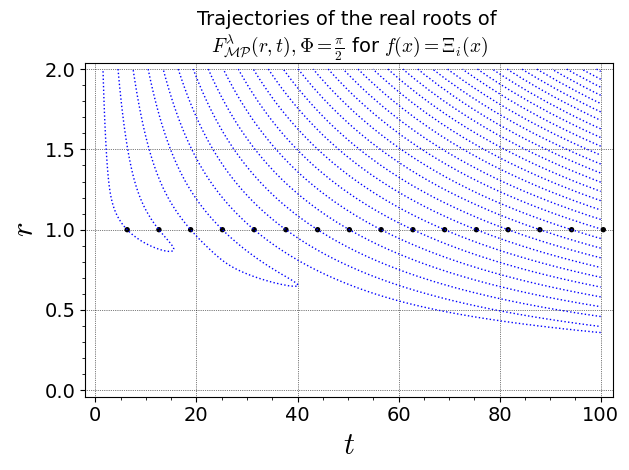

In [472]:
#Meixner Pollaczek flow using a single integral for Xi_i (no pre-computed coefficients).

var("r","t");

#Generate a plot of all ordinates of the zeros < 60 to overlay the flow graphs
var('y')
ord = []
for y in range(16):
    ord.append([2*pi()*(y+1),1])
z1=list_plot(ord, size=15, marker="o", color = "black")

CCF=ComplexBallField(1024)
RDF=RealBallField(1024)

#set lambda once here
global lambd
lambd = CCF("150")

lst = str(lambd.mid()); lstr = lst.rstrip('0')

def Xin(t):
    Xin=2*CCF(t/2).sin()/CCF(t)
    return Xin

def prefact(x,rho):
    #term1 = (1-x.pow(2)).pow(lambd-1) / ((1-x.pow(2) * (-2*rho).exp()).pow(lambd))
    term1 = (1-x.pow(2)).pow(lambd-1) / ((1-x.pow(2) * rho.pow(2)).pow(lambd))
    return term1 

def integrand(t, x, rho):
    #return prefact(x,rho)*(2*t*(x*((-1*rho).exp())).arctanh()).cos()
    return prefact(x,rho)*(2*t*(x*rho).arctanh()).cos()

def MeixPollFlow(t, rho):
    res= 4*CCF.integral(lambda y, _: integrand(CCF(t), CCF(y), CCF(rho)), CCF("0"), CCF("0.25").tanh())
    return real_part(res.mid())

#compute d/dr zk Newton approximation
def dzdrzk(k):
    tr = RDF("0.0000000001");x0 = 2*k*RDF.pi();
    while(y):
        hd = RDF(MeixPollFlow(x0 + tr*100,1+tr) - MeixPollFlow(x0,1+tr)) / (tr*100)
        h = RDF(MeixPollFlow(x0,1+tr))/hd ;x1 = x0 - h;ab = h.abs();x0 = x1
        if ab < tr:
            break
    dzdr = -1*(x1 - 2*k*RDF.pi())/(tr) 
    return dzdr

def B(x,c,d, N):
    return (x+c+1)*(x+c+d+1)*(N-x)/((2*x+c+d+1)*(2*x+c+d+2))

def D(x,c,d, N):
    return x*(x+c+d+N+1)*(x+d)/((2*x+c+d)*(2*x+c+d+1))

#closed form for sum of zeros around k-th zero
def ZS(k,c):
    zk =CCF(2*pi()*k)
    return 2*zk*CCF(c/2).sin()/(zk +c)    

#compute d/dr zk via formula
def verifyDDE(k):
    return real_part((lambd / CCF("2") - CCF(0,pi()*k))*ZS(k,CCF(0,1)) + (lambd / CCF("2") + CCF(0,pi()*k))*ZS(k,CCF(0,-1))).mid()

print("Automated checks:")
print("d/dr z_3(0) via Newton approximation : %3.6f versus formula: %3.6f (should be equal)." % ((dzdrzk(3),verifyDDE(3))))
tmp = MeixPollFlow(60,1)-Xin(60).mid()
print("Ensure 20 digits accuracy at t = 60  : %3.20f (should show 20 zeros)." % tmp)

#a1i=implicit_plot(lambda t,r:MeixPollFlow(t,r),(t,0,100),(r,0,2),color='black',fontsize=14,linestyle ="-",linewidth=1,axes_labels=['$t$',r'$r$'],title='Trajectories of the real roots of \n' + r'$F^{\lambda}_{\mathcal{MP}}(\rho,t), \lambda =$' + lstr + r'$, \Phi = \frac{\pi}{2}$ for $f(x)=\Xi_i(x)$',gridlines=True,plot_points=90)
a150i=implicit_plot(lambda t,r:MeixPollFlow(t,r),(t,0,100),(r,0,2),color='blue',fontsize=14,linestyle =":",linewidth=1,axes_labels=['$t$',r'$r$'],title='Trajectories of the real roots of \n' + r'$F^{\lambda}_{\mathcal{MP}}(r,t), \Phi = \frac{\pi}{2}$ for $f(x)=\Xi_i(x)$',gridlines=True,plot_points=210)
show(a150i + z1,aspect_ratio='automatic')

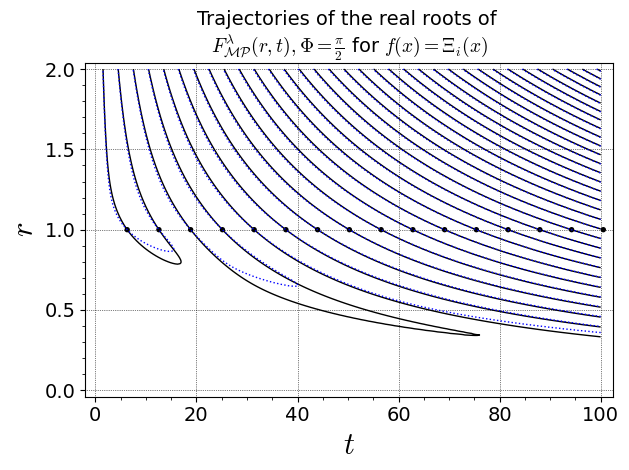

In [473]:
show(a100i + a150i + z1,aspect_ratio='automatic')

Automated checks:
d/dr z_3(0) via Newton approximation : 21.795086 versus formula: 21.795086 (should be equal).
Ensure 20 digits accuracy at t = 60  : 0.00000000000000000000 (should show 20 zeros).


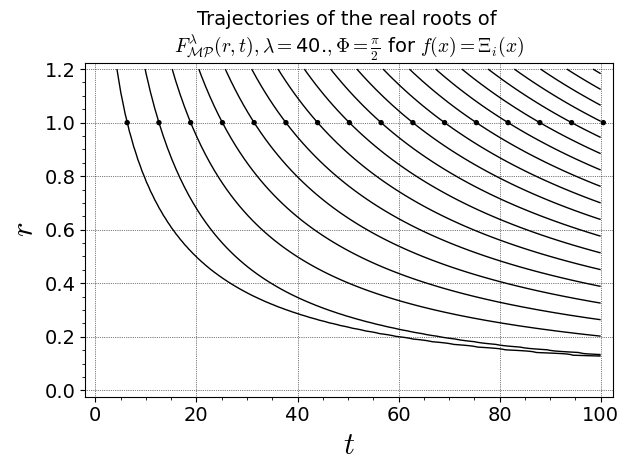

In [505]:
#Meixner Pollaczek flow using a single integral for Xi_i (no pre-computed coefficients).

var("r","t");

#Generate a plot of all ordinates of the zeros < 60 to overlay the flow graphs
var('y')
ord = []
for y in range(16):
    ord.append([2*pi()*(y+1),1])
z1=list_plot(ord, size=15, marker="o", color = "black")

CCF=ComplexBallField(624)
RDF=RealBallField(624)

#set lambda once here
global lambd
lambd = CCF("40")

lst = str(lambd.mid()); lstr = lst.rstrip('0')

def Xin(t):
    Xin=2*CCF(t/2).sin()/CCF(t)
    return Xin

def prefact(x,rho):
    #term1 = (1-x.pow(2)).pow(lambd-1) / ((1-x.pow(2) * (-2*rho).exp()).pow(lambd))
    term1 = (1-x.pow(2)).pow(lambd-1) / ((1-x.pow(2) * rho.pow(2)).pow(lambd))
    return term1 

def integrand(t, x, rho):
    #return prefact(x,rho)*(2*t*(x*((-1*rho).exp())).arctanh()).cos()
    return prefact(x,rho)*(2*t*(x*rho).arctanh()).cos()

def MeixPollFlow(t, rho):
    res= 4*CCF.integral(lambda y, _: integrand(CCF(t), CCF(y), CCF(rho)), CCF("0"), CCF("0.25").tanh())
    return real_part(res.mid())

#compute d/dr zk Newton approximation
def dzdrzk(k):
    tr = RDF("0.0000000001");x0 = 2*k*RDF.pi();
    while(y):
        hd = RDF(MeixPollFlow(x0 + tr*100,1+tr) - MeixPollFlow(x0,1+tr)) / (tr*100)
        h = RDF(MeixPollFlow(x0,1+tr))/hd ;x1 = x0 - h;ab = h.abs();x0 = x1
        if ab < tr:
            break
    dzdr = -1*(x1 - 2*k*RDF.pi())/(tr) 
    return dzdr

#closed form for sum of zeros around k-th zero
def ZS(k,c):
    zk =CCF(2*pi()*k)
    return 2*zk*CCF(c/2).sin()/(zk +c)    

#compute d/dr zk via formula
def verifyDDE(k):
    return real_part((lambd / CCF("2") - CCF(0,pi()*k))*ZS(k,CCF(0,1)) + (lambd / CCF("2") + CCF(0,pi()*k))*ZS(k,CCF(0,-1))).mid()

print("Automated checks:")
print("d/dr z_3(0) via Newton approximation : %3.6f versus formula: %3.6f (should be equal)." % ((dzdrzk(3),verifyDDE(3))))
tmp = MeixPollFlow(60,1)-Xin(60).mid()
print("Ensure 20 digits accuracy at t = 60  : %3.20f (should show 20 zeros)." % tmp)

a1i=implicit_plot(lambda t,r:MeixPollFlow(t,r),(t,0,100),(r,0,1.2),color='black',fontsize=14,linestyle ="-",linewidth=1,axes_labels=['$t$',r'$r$'],title='Trajectories of the real roots of \n' + r'$F^{\lambda}_{\mathcal{MP}}(r,t), \lambda =$' + lstr + r'$, \Phi = \frac{\pi}{2}$ for $f(x)=\Xi_i(x)$',gridlines=True,plot_points=120)
#a1i=implicit_plot(lambda t,r:MeixPollFlow(t,r),(t,0,100),(r,0,6),color='black',fontsize=14,linestyle ="-",linewidth=1,axes_labels=['$t$',r'$r$'],title='Trajectories of the real roots of \n' + r'$F^{\lambda}_{\mathcal{MP}}(r,t), \Phi = \frac{\pi}{2}$ for $f(x)=\Xi_i(x)$',gridlines=True,plot_points=60)
show(a1i + z1,aspect_ratio='automatic')

Automated checks:
d/dr z_3(0) via Newton approximation : 19.644830 versus formula: 19.644830 (should be equal).
Ensure 20 digits accuracy at t = 60  : 0.00000000000000000000 (should show 20 zeros).


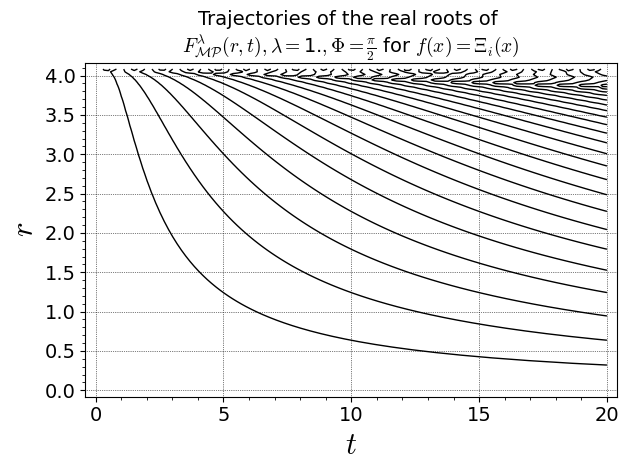

In [22]:
#Meixner Pollaczek flow using a single integral for Xi_i (no pre-computed coefficients).

var("r","t");

#Generate a plot of all ordinates of the zeros < 60 to overlay the flow graphs
var('y')
ord = []
for y in range(16):
    ord.append([2*pi()*(y+1),1])
z1=list_plot(ord, size=15, marker="o", color = "black")

CCF=ComplexBallField(1024)
RDF=RealBallField(1024)

#set lambda once here
global lambd
lambd = CCF("1")

lst = str(lambd.mid()); lstr = lst.rstrip('0')

def Xin(t):
    Xin=2*CCF(t/2).sin()/CCF(t)
    return Xin

def prefact(x,rho):
    term1 = (1-x.pow(2)).pow(lambd-1) / ((1-x.pow(2) * rho.pow(2)).pow(lambd))
    return term1 

def integrand(t, x, rho):
    return prefact(x,rho)*(2*t*(x*rho).arctanh()).cos()

def MeixPollFlow(t, rho):
    res= 4*CCF.integral(lambda y, _: integrand(CCF(t), CCF(y), CCF(rho)), CCF("0"), CCF("0.25").tanh())
    return real_part(res.mid())

#compute d/dr zk Newton approximation
def dzdrzk(k):
    tr = RDF("0.0000000001");x0 = 2*k*RDF.pi();
    while(y):
        hd = RDF(MeixPollFlow(x0 + tr*100,1+tr) - MeixPollFlow(x0,1+tr)) / (tr*100)
        h = RDF(MeixPollFlow(x0,1+tr))/hd ;x1 = x0 - h;ab = h.abs();x0 = x1
        if ab < tr:
            break
    dzdr = -1*(x1 - 2*k*RDF.pi())/(tr) 
    return dzdr

#closed form for sum of zeros around k-th zero
def ZS(k,c):
    zk =CCF(2*pi()*k)
    return 2*zk*CCF(c/2).sin()/(zk +c)    

#compute d/dr zk via formula
def verifyDDE(k):
    return real_part((lambd / CCF("2") - CCF(0,pi()*k))*ZS(k,CCF(0,1)) + (lambd / CCF("2") + CCF(0,pi()*k))*ZS(k,CCF(0,-1))).mid()

print("Automated checks:")
print("d/dr z_3(0) via Newton approximation : %3.6f versus formula: %3.6f (should be equal)." % ((dzdrzk(3),verifyDDE(3))))
tmp = MeixPollFlow(60,1)-Xin(60).mid()
print("Ensure 20 digits accuracy at t = 60  : %3.20f (should show 20 zeros)." % tmp)

a1i=implicit_plot(lambda t,r:MeixPollFlow(t,r),(t,0,20),(r,0,4.0829),color='black',fontsize=14,linestyle ="-",linewidth=1,axes_labels=['$t$',r'$r$'],title='Trajectories of the real roots of \n' + r'$F^{\lambda}_{\mathcal{MP}}(r,t), \lambda =$' + lstr + r'$, \Phi = \frac{\pi}{2}$ for $f(x)=\Xi_i(x)$',gridlines=True,plot_points=120)
#a100i=implicit_plot(lambda t,r:MeixPollFlow(t,r),(t,0,100),(r,0,2),color='black',fontsize=14,linestyle ="-",linewidth=1,axes_labels=['$t$',r'$r$'],title='Trajectories of the real roots of \n' + r'$F^{\lambda}_{\mathcal{MP}}(r,t), \Phi = \frac{\pi}{2}$ for $f(x)=\Xi_i(x)$',gridlines=True,plot_points=90)
show(a1i,aspect_ratio='automatic')

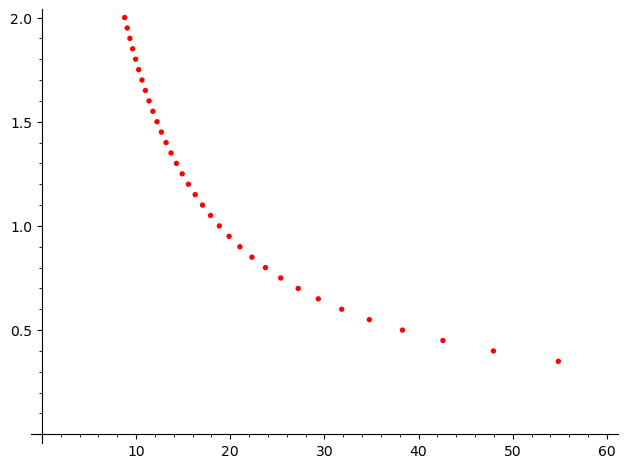

In [16]:
var("r");

#Generate a plot of all ordinates of the zeros < 60 to overlay the flow graphs
ord = []
r = 0
while r < 2:
    r = r + 0.05
    ord.append([3*pi()/(2*arctanh(r*tanh(1/4))),r])
z2=list_plot(ord, size=15, marker="o", color = "red",xmin=0,xmax=60,ymin=0,ymax=2)
z2

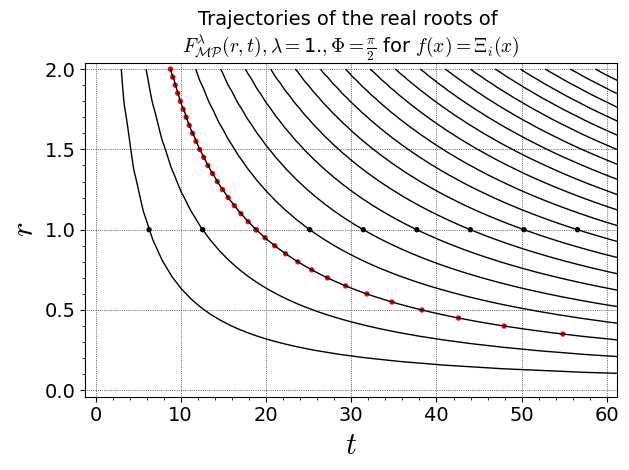

In [13]:
show(a1i + z1+z2,aspect_ratio='automatic')